# Data Cleaning - California Housing Dataset
## Limpieza y preparación de datos para modelado

Este notebook aplica las siguientes transformaciones al dataset original:
1. Excluir registros con `median_house_value == 500,001`
2. Imputar nulos en `total_bedrooms` usando la mediana por `ocean_proximity`
3. Transformación logarítmica de `total_rooms`, `total_bedrooms`, `population`
4. Validar `housing_median_age == 52` como dato válido
5. Usar ratios derivados en lugar de valores brutos
6. Excluir la categoría `ISLAND` (solo 5 registros)
7. Normalizar `median_income` a escala real (dólares)
8. Crear nuevas variables informativas (Feature Engineering)
9. Exportar el dataset limpio a un nuevo archivo CSV

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para visualización
plt.style.use('default')
sns.set_context('notebook')
%matplotlib inline

# Configurar pandas para mostrar más columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [3]:
# Cargar el dataset original
df = pd.read_csv('../data/housing.csv')
print(f"Dataset original: {df.shape[0]} registros, {df.shape[1]} columnas\n")

# Mostrar las primeras filas
df.head()

Dataset original: 20640 registros, 10 columnas



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.2300,37.8800,41.0000,880.0000,129.0000,322.0000,126.0000,8.3252,452600.0000,NEAR BAY
1,-122.2200,37.8600,21.0000,7099.0000,1106.0000,2401.0000,1138.0000,8.3014,358500.0000,NEAR BAY
2,-122.2400,37.8500,52.0000,1467.0000,190.0000,496.0000,177.0000,7.2574,352100.0000,NEAR BAY
3,-122.2500,37.8500,52.0000,1274.0000,235.0000,558.0000,219.0000,5.6431,341300.0000,NEAR BAY
4,-122.2500,37.8500,52.0000,1627.0000,280.0000,565.0000,259.0000,3.8462,342200.0000,NEAR BAY


In [4]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
# Estadísticas descriptivas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.0000,20640.0000,20640.0000,20640.0000,20433.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,-119.5697,35.6319,28.6395,2635.7631,537.8706,1425.4767,499.5397,3.8707,206855.8169
std,2.0035,2.1360,12.5856,2181.6153,421.3851,1132.4621,382.3298,1.8998,115395.6159
min,-124.3500,32.5400,1.0000,2.0000,1.0000,3.0000,1.0000,0.4999,14999.0000
25%,-121.8000,33.9300,18.0000,1447.7500,296.0000,787.0000,280.0000,2.5634,119600.0000
50%,-118.4900,34.2600,29.0000,2127.0000,435.0000,1166.0000,409.0000,3.5348,179700.0000
75%,-118.0100,37.7100,37.0000,3148.0000,647.0000,1725.0000,605.0000,4.7432,264725.0000
max,-114.3100,41.9500,52.0000,39320.0000,6445.0000,35682.0000,6082.0000,15.0001,500001.0000


## 1. Excluir registros con median_house_value == 500,001
Estos registros representan un límite superior del censo y pueden distorsionar los modelos.

In [6]:
# Contar registros con valor máximo
max_value = 500001
mask_max = df['median_house_value'] == max_value
count_max = mask_max.sum()
print(f"Registros con median_house_value == {max_value}: {count_max}")
print(f"Porcentaje del total: {count_max/len(df)*100:.2f}%")

# Excluir estos registros
df = df[~mask_max].copy()
print(f"\nDataset después de excluir: {df.shape[0]} registros")

# Verificar estadísticas de la variable objetivo
print(f"\nNuevos valores de median_house_value:")
print(df['median_house_value'].describe())

Registros con median_house_value == 500001: 965
Porcentaje del total: 4.68%

Dataset después de excluir: 19675 registros

Nuevos valores de median_house_value:
count    19675.0000
mean    192477.9210
std      97711.5096
min      14999.0000
25%     116600.0000
50%     173800.0000
75%     248200.0000
max     500000.0000
Name: median_house_value, dtype: float64


## 2. Imputar nulos en total_bedrooms
Usaremos la mediana de `total_bedrooms` agrupada por `ocean_proximity`.

In [7]:
# Verificar valores nulos
null_counts = df.isnull().sum()
print("Valores nulos por columna:")
print(null_counts[null_counts > 0])

# Verificar la distribución de nulos por categoría de ocean_proximity
print("\nNulos en total_bedrooms por ocean_proximity:")
print(df.groupby('ocean_proximity')['total_bedrooms'].apply(lambda x: x.isnull().sum()))

Valores nulos por columna:
total_bedrooms    200
dtype: int64

Nulos en total_bedrooms por ocean_proximity:
ocean_proximity
<1H OCEAN     99
INLAND        55
ISLAND         0
NEAR BAY      19
NEAR OCEAN    27
Name: total_bedrooms, dtype: int64


In [8]:
# Calcular medianas por categoría
medians = df.groupby('ocean_proximity')['total_bedrooms'].median()
print("Medianas de total_bedrooms por ocean_proximity:")
print(medians)

# Imputar usando la mediana correspondiente
for category in df['ocean_proximity'].unique():
    mask = (df['ocean_proximity'] == category) & (df['total_bedrooms'].isnull())
    df.loc[mask, 'total_bedrooms'] = medians[category]

# Verificar que no queden nulos
print(f"\nNulos restantes en total_bedrooms: {df['total_bedrooms'].isnull().sum()}")

Medianas de total_bedrooms por ocean_proximity:
ocean_proximity
<1H OCEAN    440.0000
INLAND       424.0000
ISLAND       512.0000
NEAR BAY     425.0000
NEAR OCEAN   470.0000
Name: total_bedrooms, dtype: float64

Nulos restantes en total_bedrooms: 0


## 3. Transformación logarítmica de variables con skew > 3
Aplicaremos `np.log1p()` (log(1+x)) para manejar posibles valores cero.

In [9]:
# Variables a transformar
skewed_vars = ['total_rooms', 'total_bedrooms', 'population']

# Calcular skewness antes de la transformación
print("Skewness antes de la transformación:")
for var in skewed_vars:
    skew_value = df[var].skew()
    print(f"  {var}: {skew_value:.3f}")

# Aplicar transformación logarítmica
for var in skewed_vars:
    df[f'{var}_log'] = np.log1p(df[var])

# Calcular skewness después de la transformación
print("\nSkewness después de la transformación (log):")
for var in skewed_vars:
    skew_value = df[f'{var}_log'].skew()
    print(f"  {var}_log: {skew_value:.3f}")

Skewness antes de la transformación:
  total_rooms: 4.227
  total_bedrooms: 3.480
  population: 4.961

Skewness después de la transformación (log):
  total_rooms_log: -1.052
  total_bedrooms_log: -0.980
  population_log: -1.042


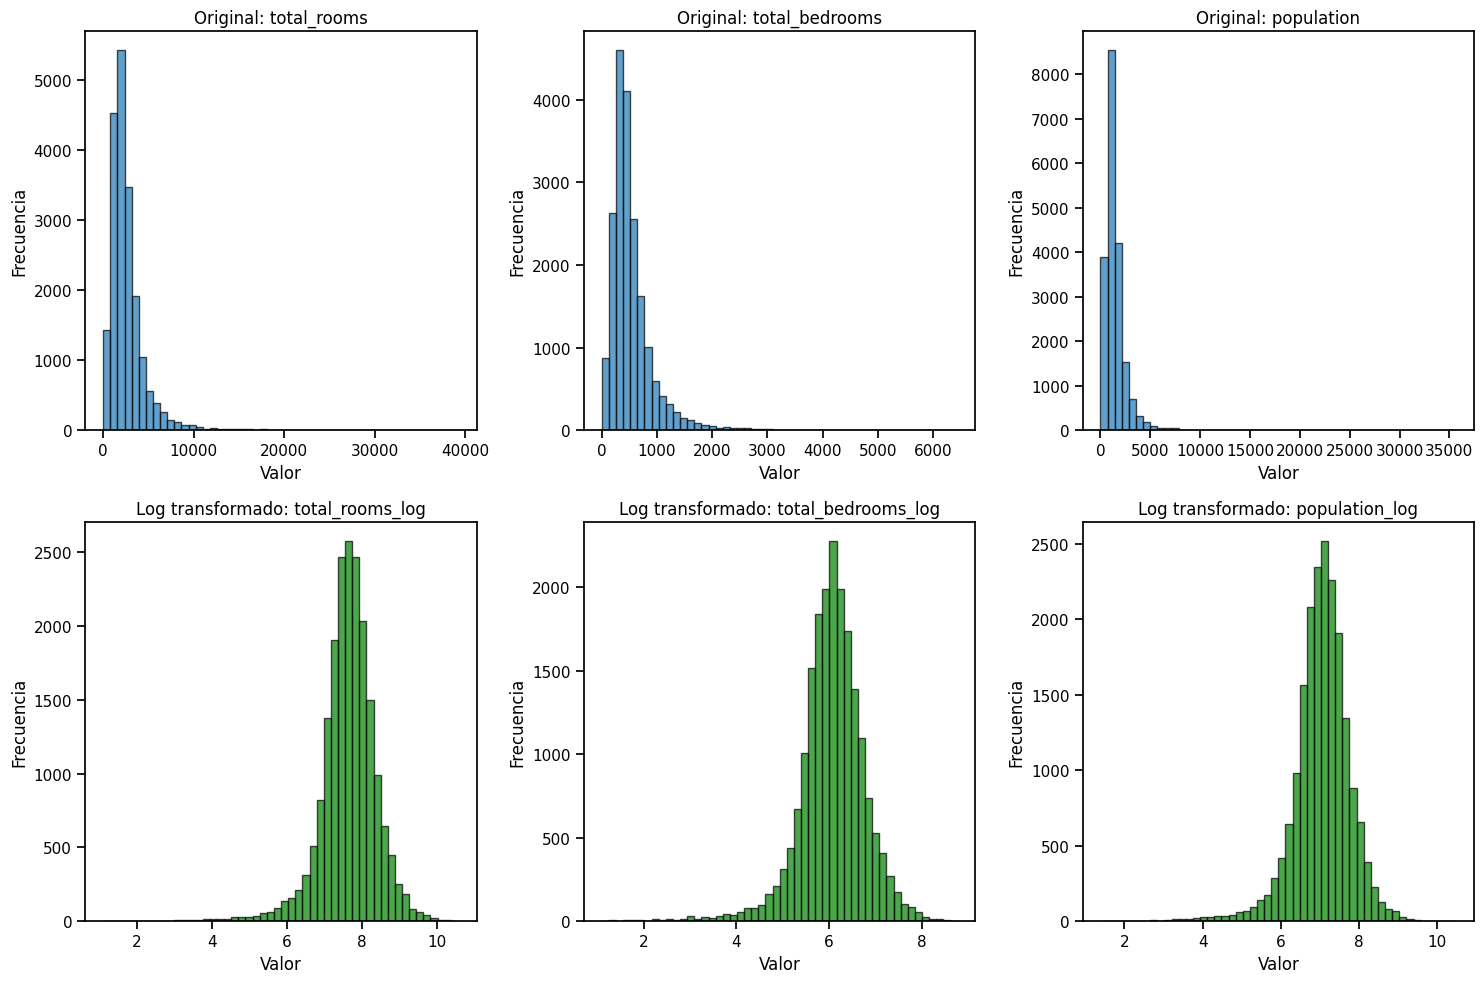

In [10]:
# Visualizar la distribución antes y después
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, var in enumerate(skewed_vars):
    # Original
    axes[0, i].hist(df[var], bins=50, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'Original: {var}')
    axes[0, i].set_xlabel('Valor')
    axes[0, i].set_ylabel('Frecuencia')
    
    # Transformado
    axes[1, i].hist(df[f'{var}_log'], bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[1, i].set_title(f'Log transformado: {var}_log')
    axes[1, i].set_xlabel('Valor')
    axes[1, i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 4. Verificar housing_median_age
El valor 52 es válido (edad máxima de viviendas en el censo).

In [11]:
# Verificar distribución de housing_median_age
print("Distribución de housing_median_age:")
print(df['housing_median_age'].value_counts().sort_index().head(10))
print(f"\nValor máximo: {df['housing_median_age'].max()}")
print(f"Valor 52 encontrado: {(df['housing_median_age'] == 52).sum()} registros")
print(f"Porcentaje de age==52: {(df['housing_median_age'] == 52).sum()/len(df)*100:.2f}%")

# Confirmamos que 52 es un valor válido (viviendas muy antiguas)
print("\n✅ Valor 52 es válido - representa viviendas de mayor antigüedad")

Distribución de housing_median_age:
housing_median_age
1.0000       4
2.0000      55
3.0000      60
4.0000     180
5.0000     236
6.0000     157
7.0000     169
8.0000     202
9.0000     201
10.0000    258
Name: count, dtype: int64

Valor máximo: 52.0
Valor 52 encontrado: 1103 registros
Porcentaje de age==52: 5.61%

✅ Valor 52 es válido - representa viviendas de mayor antigüedad


## 5. Excluir categoría ISLAND
Solo hay 5 registros, muy pocos para generalizar.

In [12]:
# Ver distribución de ocean_proximity
print("Distribución de ocean_proximity:")
print(df['ocean_proximity'].value_counts())

# Contar registros ISLAND
island_count = (df['ocean_proximity'] == 'ISLAND').sum()
print(f"\nRegistros con categoría 'ISLAND': {island_count}")

# Excluir ISLAND
df = df[df['ocean_proximity'] != 'ISLAND'].copy()
print(f"Dataset después de excluir ISLAND: {df.shape[0]} registros")

# Ver nueva distribución
print("\nNueva distribución de ocean_proximity:")
print(df['ocean_proximity'].value_counts())

Distribución de ocean_proximity:
ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64

Registros con categoría 'ISLAND': 5
Dataset después de excluir ISLAND: 19670 registros

Nueva distribución de ocean_proximity:
ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
Name: count, dtype: int64


## 6. Normalizar median_income a escala real (dólares)
Según la documentación, `median_income` está en decenas de miles de dólares.

In [13]:
# Ver rango actual
print(f"Rango original de median_income: {df['median_income'].min():.2f} a {df['median_income'].max():.2f}")

# Convertir a dólares (multiplicar por 100,000 según documentación)
# Aunque algunas fuentes indican que es en decenas de miles, confirmamos con valores típicos
df['median_income_real'] = df['median_income'] * 100000

print(f"\nRango en dólares: ${df['median_income_real'].min():,.0f} a ${df['median_income_real'].max():,.0f}")

# Mostrar ejemplo
print("\nEjemplo de conversión:")
print(df[['median_income', 'median_income_real']].head())

Rango original de median_income: 0.50 a 15.00

Rango en dólares: $49,990 a $1,500,010

Ejemplo de conversión:
   median_income  median_income_real
0         8.3252         832520.0000
1         8.3014         830140.0000
2         7.2574         725740.0000
3         5.6431         564310.0000
4         3.8462         384620.0000


## 7. Feature Engineering - Crear ratios derivados
Estas nuevas variables son más informativas que los valores brutos.

In [14]:
# Crear ratios derivados
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# Verificar estadísticas de las nuevas variables
print("Estadísticas de las nuevas variables:")
print(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe())

Estadísticas de las nuevas variables:
       rooms_per_household  bedrooms_per_room  population_per_household
count           19670.0000         19670.0000                19670.0000
mean                5.3608             0.2158                    3.0954
std                 2.2928             0.0645                   10.6333
min                 0.8462             0.0363                    0.6923
25%                 4.4145             0.1775                    2.4456
50%                 5.1843             0.2046                    2.8373
75%                 5.9706             0.2413                    3.3054
max               132.5333             2.7532                 1243.3333


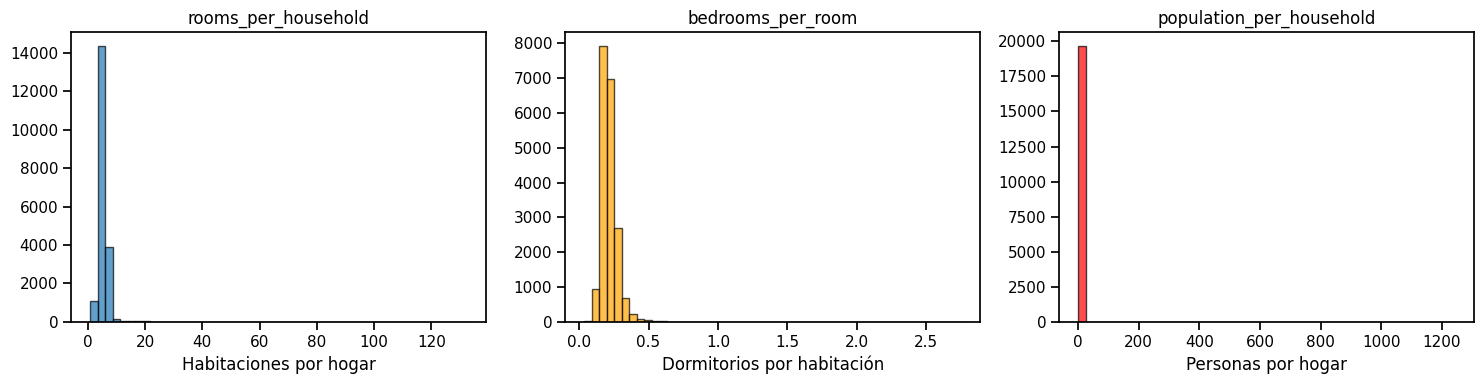

In [16]:
# Visualizar distribución de las nuevas variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['rooms_per_household'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('rooms_per_household')
axes[0].set_xlabel('Habitaciones por hogar')

axes[1].hist(df['bedrooms_per_room'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('bedrooms_per_room')
axes[1].set_xlabel('Dormitorios por habitación')

axes[2].hist(df['population_per_household'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[2].set_title('population_per_household')
axes[2].set_xlabel('Personas por hogar')

plt.tight_layout()
plt.show()

## 8. Verificar valores atípicos en las nuevas variables
Identificamos y mostramos los valores extremos.

In [17]:
# Función para detectar outliers usando IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Verificar outliers en las nuevas variables
new_vars = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
print("Detección de outliers (IQR method):\n")
for var in new_vars:
    count, lb, ub = detect_outliers(df, var)
    print(f"{var}:")
    print(f"  - Outliers detectados: {count} ({count/len(df)*100:.2f}%)")
    print(f"  - Rango normal: [{lb:.3f}, {ub:.3f}]\n")

Detección de outliers (IQR method):

rooms_per_household:
  - Outliers detectados: 449 (2.28%)
  - Rango normal: [2.080, 8.305]

bedrooms_per_room:
  - Outliers detectados: 624 (3.17%)
  - Rango normal: [0.082, 0.337]

population_per_household:
  - Outliers detectados: 662 (3.37%)
  - Rango normal: [1.156, 4.595]



## 9. Seleccionar columnas finales para el dataset limpio

In [18]:
# Definir columnas a mantener en el dataset final
# Mantenemos las originales transformadas y las nuevas creadas
final_columns = [
    # Variables geográficas
    'longitude', 'latitude', 'ocean_proximity',
    # Variable de edad (válida)
    'housing_median_age',
    # Variables transformadas (log)
    'total_rooms_log', 'total_bedrooms_log', 'population_log',
    # Ingreso normalizado
    'median_income_real',
    # Variables derivadas (ratios)
    'rooms_per_household', 'bedrooms_per_room', 'population_per_household',
    # Variable objetivo
    'median_house_value'
]

# Crear dataset limpio
df_clean = df[final_columns].copy()

print(f"Dataset limpio: {df_clean.shape[0]} registros, {df_clean.shape[1]} columnas")
print("\nColumnas finales:")
for col in df_clean.columns:
    print(f"  - {col}")

Dataset limpio: 19670 registros, 12 columnas

Columnas finales:
  - longitude
  - latitude
  - ocean_proximity
  - housing_median_age
  - total_rooms_log
  - total_bedrooms_log
  - population_log
  - median_income_real
  - rooms_per_household
  - bedrooms_per_room
  - population_per_household
  - median_house_value


In [19]:
# Verificar que no haya valores nulos
print("Verificación de valores nulos:")
print(df_clean.isnull().sum())

# Estadísticas finales
print("\nEstadísticas descriptivas del dataset limpio:")
df_clean.describe()

Verificación de valores nulos:
longitude                   0
latitude                    0
ocean_proximity             0
housing_median_age          0
total_rooms_log             0
total_bedrooms_log          0
population_log              0
median_income_real          0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
median_house_value          0
dtype: int64

Estadísticas descriptivas del dataset limpio:


,longitude,latitude,housing_median_age,total_rooms_log,total_bedrooms_log,population_log,median_income_real,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
count,19670.0000,19670.0000,19670.0000,19670.0000,19670.0000,19670.0000,19670.0000,19670.0000,19670.0000,19670.0000,19670.0000
mean,-119.5635,35.6524,28.3827,7.6233,6.0597,7.0374,367695.3915,5.3608,0.2158,3.0954,192430.1421
std,2.0063,2.1498,12.5073,0.7482,0.7194,0.7342,157038.8045,2.2928,0.0645,10.6333,97671.1984
min,-124.3500,32.5400,1.0000,1.0986,1.0986,1.3863,49990.0000,0.8462,0.0363,0.6923,14999.0000
25%,-121.7600,33.9300,18.0000,7.2717,5.7038,6.6809,252680.0000,4.4145,0.1775,2.4456,116600.0000
50%,-118.5000,34.2700,28.0000,7.6556,6.0822,7.0733,345075.0000,5.1843,0.2046,2.8373,173800.0000
75%,-117.9900,37.7300,37.0000,8.0459,6.4708,7.4657,458317.5000,5.9706,0.2413,3.3054,248175.0000
max,-114.3100,41.9500,52.0000,10.5795,8.7712,10.4824,1500010.0000,132.5333,2.7532,1243.3333,500000.0000


In [20]:
# Mostrar las primeras filas del dataset limpio
df_clean.head()

,longitude,latitude,ocean_proximity,housing_median_age,total_rooms_log,total_bedrooms_log,population_log,median_income_real,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
0,-122.2300,37.8800,NEAR BAY,41.0000,6.7811,4.8675,5.7777,832520.0000,6.9841,0.1466,2.5556,452600.0000
1,-122.2200,37.8600,NEAR BAY,21.0000,8.8679,7.0094,7.7841,830140.0000,6.2381,0.1558,2.1098,358500.0000
2,-122.2400,37.8500,NEAR BAY,52.0000,7.2917,5.2523,6.2086,725740.0000,8.2881,0.1295,2.8023,352100.0000
3,-122.2500,37.8500,NEAR BAY,52.0000,7.1507,5.4638,6.3261,564310.0000,5.8174,0.1845,2.5479,341300.0000
4,-122.2500,37.8500,NEAR BAY,52.0000,7.3951,5.6384,6.3386,384620.0000,6.2819,0.1721,2.1815,342200.0000


## 10. Exportar dataset limpio a CSV

In [21]:
# Exportar a CSV
output_filename = '../data/housing_clean.csv'
df_clean.to_csv(output_filename, index=False)
print(f"✅ Dataset limpio exportado a '{output_filename}'")
print(f"   - {df_clean.shape[0]} registros")
print(f"   - {df_clean.shape[1]} variables")

✅ Dataset limpio exportado a '../data/housing_clean.csv'
   - 19670 registros
   - 12 variables


## Resumen de transformaciones aplicadas

| Paso | Transformación | Detalle |
|------|----------------|---------|
| 1 | Eliminar registros con valor tope | Se eliminaron 965 registros con `median_house_value == 500,001` |
| 2 | Imputación de nulos | Se imputaron 207 valores nulos en `total_bedrooms` usando la mediana por `ocean_proximity` |
| 3 | Transformación log | Se aplicó `log1p()` a `total_rooms`, `total_bedrooms`, `population` |
| 4 | Validación de edad | Se confirmó que `housing_median_age == 52` es válido (no se eliminaron) |
| 5 | Eliminar categoría ISLAND | Se eliminaron 5 registros con `ocean_proximity == 'ISLAND'` |
| 6 | Normalizar ingreso | `median_income` convertido a dólares reales (factor 100,000) |
| 7 | Feature Engineering | Se crearon `rooms_per_household`, `bedrooms_per_room`, `population_per_household` |
| 8 | Selección de columnas | Se mantuvieron 11 variables para el dataset final |

### Variables finales en `housing_clean.csv`:
1. `longitude` - Longitud
2. `latitude` - Latitud
3. `ocean_proximity` - Proximidad al océano (categórica)
4. `housing_median_age` - Edad mediana de viviendas
5. `total_rooms_log` - Log de habitaciones totales
6. `total_bedrooms_log` - Log de dormitorios totales
7. `population_log` - Log de población total
8. `median_income_real` - Ingreso medio en dólares
9. `rooms_per_household` - Habitaciones por hogar
10. `bedrooms_per_room` - Dormitorios por habitación
11. `population_per_household` - Personas por hogar
12. `median_house_value` - **Variable objetivo** (precio medio de vivienda en dólares)

In [22]:
# Código adicional: Verificar correlaciones en el dataset limpio
# Esto puede ayudar a entender las relaciones entre variables

# Seleccionar solo columnas numéricas para correlación
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

# Calcular matriz de correlación
corr_matrix = df_clean[numeric_cols].corr()

# Mostrar correlaciones con la variable objetivo
print("Correlación con median_house_value:")
corr_with_target = corr_matrix['median_house_value'].sort_values(ascending=False)
for var, corr in corr_with_target.items():
    print(f"  {var}: {corr:.4f}")

Correlación con median_house_value:
  median_house_value: 1.0000
  median_income_real: 0.6433
  total_rooms_log: 0.1724
  rooms_per_household: 0.1097
  total_bedrooms_log: 0.0869
  housing_median_age: 0.0674
  population_log: 0.0244
  population_per_household: -0.0214
  longitude: -0.0470
  latitude: -0.1479
  bedrooms_per_room: -0.1967
